In [12]:
import numpy as np
from reader import *
import matplotlib.pyplot as plt
import math
from scipy import interpolate
import sys

In [16]:
geo = Reader("drafttube_shapes/baseline1/geo/elbow.geo", cascade=False)

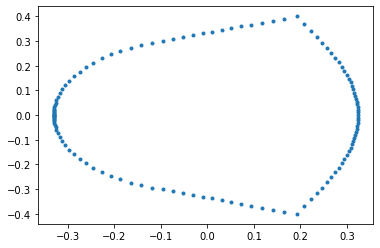

In [17]:
pts = []

'''
How layers are arranged:
# 256 for first layer
# 128 for layers 2-30
# 31st layer has the non 2D part
# 32nd : even 3970-4050, odd 4051-4097, even 4100-4146, odd 4147-4223
# 33rd: odd 3969-4049, even 4052-4098, oddd 4099-4145, even 4148-4224
# 34-63 layer: 4225 - 8064 are layers of 128
# 64th: 8065-8093, 8107, 8122, 8127-8175, 8225-8248, 8273-8296
# 65th: 8094-8106, 8108-8121, 8123-8126, 8176-8224, 8249-8272, 8297-8320

def main():

# get the 360 points for the layers
for k in range(1, 66):
    if k == 1:
        index = range(256)
    elif k <= 30 or (k>=34 and k<=63):
        index = range((k-1)*128, (k-1)*128 + 128)
    #what to do with layer 31 ??
    elif k == 32:
        index = list(range(3969, 4051, 2))+list(range(4050, 4098, 2))+list(range(4099, 4147, 2))+list(range(4146, 4223, 2))
    elif k == 33:
        index = list(range(3968, 4050, 2))+list(range(4051, 4099, 2))+list(range(4098, 4146, 2))+list(range(4147, 4225, 2))
    elif k = 64:
        index = list(range(8064,8093)) + list(range(8126, 8175)) + list(range(8224, 8248))+ list(range(8272, 8296)) + [8106, 8121]
    else:
        index = list(range(8093,8106)) + list(range(8107, 8121)) + list(range(8122, 8126))+ list(range(8175, 8224))+list(range(8248,8272))+list(range(8296, 8320))
    #call interpolating function with inout index

for i in range(0, 2000):
    #call weighting function, which should print to text file
'''
index = range((31-1)*128, (31-1)*128 + 128)
#index = list(range(8064,8093)) + list(range(8126, 8175)) + list(range(8224, 8248))+ list(range(8272, 8296)) + [8106, 8121]
#index = list(range(8093,8106)) + list(range(8107, 8121)) + list(range(8122, 8126))+ list(range(8175, 8224))+list(range(8248,8272))+list(range(8296, 8320))

for i in index:
    pts.append(np.array(geo.collate_xyz(i)))
points = np.asarray(pts)

x_mid = np.average(points[:,0])
z_mid = np.average(points[:,2])

for i in range(0, 128):
    points[i][0] = points[i][0] - x_mid
    points[i][2] = points[i][2] - z_mid
    # eventually will equal the origin line
plt.plot(points[:, 0], points[:,1], '.')

ind = closest_index(points[:, 1], 0)
phi = np.arctan(np.array(abs(points[ind][2]/points[ind][0]))) # angle of the plane 

In [11]:
# need to get angle bc z values are not the same
# 1 shift plant so centered at (0,0,0) based on centerline
# 2 rotate plane around y axis by the angle
# --> find distance from origin, this is the r value
# --> how do i find the angle? anlge between lines (1) z axis and (2) the line connecting point to origin

y_axis = [0,1,0]
for i in range(0, 128):
    #still need to account for centerpoint in all of the points and adjustment to (0, 0, 0)
    # this is why plot looks like a mess
    pt = points[i]
    dot_product = np.dot(y_axis, pt)
    
    y = np.array(y_axis)
    p = np.array(pt)

    # account for specific quadrant, is there a function that gives these values for arccos?
    theta_original = np.arccos(dot_product/(np.linalg.norm(p)*np.linalg.norm(y)))
    if p[0] > 0 and p[1] >= 0:
        theta = (math.pi/2) - theta_original
    elif p[1] >= 0:
        theta = (math.pi/2) + theta_original
    elif p[0] < 0 and p[1] < 0:
        theta = (math.pi/2) + theta_original
    else:
        theta = (5*math.pi/2) - theta_original
    r = np.linalg.norm(p)
    points[i] = [r, theta, 0]
print(points)


[[0.42467968 3.14710014 0.        ]
 [0.42467879 3.14159265 0.        ]
 [0.42467929 3.15300276 0.        ]
 [0.42467706 3.1596925  0.        ]
 [0.4246722  3.16755526 0.        ]
 [0.42466425 3.17696842 0.        ]
 [0.42464962 3.18829882 0.        ]
 [0.42462108 3.20190152 0.        ]
 [0.42457801 3.21812182 0.        ]
 [0.4244976  3.2372932  0.        ]
 [0.42438358 3.25975115 0.        ]
 [0.42428795 3.28585721 0.        ]
 [0.42423439 3.31600101 0.        ]
 [0.42403911 3.35052911 0.        ]
 [0.42371975 3.38992434 0.        ]
 [0.42333108 3.43482785 0.        ]
 [0.41780646 3.48240207 0.        ]
 [0.41200096 3.53459968 0.        ]
 [0.40521203 3.59164168 0.        ]
 [0.39758723 3.65357762 0.        ]
 [0.38911988 3.72046257 0.        ]
 [0.37998173 3.79226141 0.        ]
 [0.37041316 3.8688469  0.        ]
 [0.36071319 3.94996836 0.        ]
 [0.35099105 4.03536612 0.        ]
 [0.34182656 4.1243593  0.        ]
 [0.33374773 4.21603474 0.        ]
 [0.32771124 4.3088149  0.  

In [19]:
for i in range(0, 128):
    x0, y0, z0 = plane_rotation(-phi,points[i])
    r, theta = cart2pol(x0, y0)
    points[i] = [r, theta, z0]
print(points)

[[ 4.24679676e-01 -3.13608517e+00 -7.21869513e-06]
 [ 4.24678789e-01  3.14159265e+00 -2.77555756e-17]
 [ 4.24679285e-01 -3.13018254e+00 -2.68763184e-05]
 [ 4.24677054e-01 -3.12349281e+00 -6.39039993e-05]
 [ 4.24672181e-01 -3.11563005e+00 -1.27732583e-04]
 [ 4.24664187e-01 -3.10621688e+00 -2.34249717e-04]
 [ 4.24649429e-01 -3.09488647e+00 -4.03616533e-04]
 [ 4.24620561e-01 -3.08128372e+00 -6.61727124e-04]
 [ 4.24576699e-01 -3.06506325e+00 -1.05592224e-03]
 [ 4.24494497e-01 -3.04589140e+00 -1.62207827e-03]
 [ 4.24376510e-01 -3.02343218e+00 -2.44952838e-03]
 [ 4.24271683e-01 -2.99732253e+00 -3.71496648e-03]
 [ 4.24197498e-01 -2.96716897e+00 -5.59448339e-03]
 [ 4.23962954e-01 -2.93261812e+00 -8.03595269e-03]
 [ 4.23569064e-01 -2.89317075e+00 -1.12993282e-02]
 [ 4.23036922e-01 -2.84814750e+00 -1.57787661e-02]
 [ 4.17521775e-01 -2.80054141e+00 -1.54209215e-02]
 [ 4.11727461e-01 -2.74831022e+00 -1.50095919e-02]
 [ 4.04951832e-01 -2.69123318e+00 -1.45190079e-02]
 [ 3.97342439e-01 -2.62926145e+

In [302]:

#ideally will have the points for the center based on the centerline code

# once interpolation is done in cartesian, this will find the r value for a given s and theta
# how do i find the location of s and the two planes 
#   --> have length of centerline, then can find the distance along line s is based on the total number
#   --> what do i do with the parts between sections


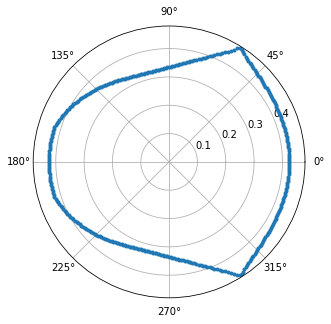

In [303]:
r_theta = np.array([[points[i][0], points[i][1]] for i in range(len(points))]) # get r and theta from points
sort = np.argsort(r_theta[:,1])
r_theta_sorted = r_theta[sort,:] # sorted pairs
#print(r_theta_sorted)

r_plot = [r_theta_sorted[i][0] for i in range(len(r_theta_sorted))] # get r values form sorted
theta_plot = [r_theta_sorted[i][1] for i in range(len(r_theta_sorted))] # get theta values from sorted
#plt.polar(theta_plot, r_plot, '.')

plt.figure(figsize=(5, 5))
f = interpolate.PchipInterpolator(theta_plot, r_plot, extrapolate= True)

t = [i for i in range(0, 360)]
t_rad = [np.deg2rad(t[i]) for i in range(len(t))]
plt.polar(t_rad, f(t_rad), '.')

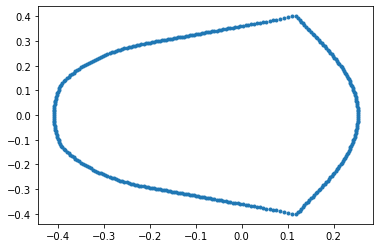

In [310]:
points_final = []
r_values = f(t_rad)
for i in range(len(t)):
    point = [r_values[i]*np.cos(t_rad[i]), r_values[i]*np.sin(t_rad[i]), 0]
    x, y, z = plane_rotation(phi,point)
    #print(x, i)
    xf = x + x_mid
    zf = z + z_mid
    points_final.append([xf, y, zf])

points_final = np.array(points_final)
plt.plot(points_final[:, 0], points_final[:,1], '.')

In [7]:
# rotate in 3d space
# takes in a point in cartesian coordinates 3d space and rotates it
def plane_rotation(phi, point):
    x = point[0]*np.cos(-phi) + point[2]*np.sin(-phi)
    y = point[1]
    z = -point[0]*np.sin(-phi) + point[2]*np.cos(-phi)
    return x, y, z

def cart2pol(x, y):
    """Convert a set of cartesian coordinates x, y to polar coordinates r, theta (default to radians)"""
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return r, theta

def closest_index(lst, K):
    """Return the nearest value to integer K in a list of floating point values lst"""
    ind = min(range(len(lst)), key = lambda i: abs(lst[i] - K))
    return ind

# takes in a list for point and the array of centerpoints as points
#returns the index of the closest point, the second closest point
def closest2index(points, point):
    points = np.asarray(points)
    distances = np.sum((points - point)**2)
    closest = min(range(len(distances)), key = lambda i: (distances[i]))
    secondvalue = sys.maxint
    for i in range(len(distances)):
        if distances[i] < secondvalue and distances[i] > distances[closest]:
            second = i
            secondvalue = distances[i]
    return closest, second

def closest(lst, K):
    """Return the nearest value to integer K in a list of floating point values lst"""
    ind = min(range(len(lst)), key = lambda i: abs(lst[i] - K))
    return [lst[ind - 1], lst[ind]]

def interpolate_polar(x, y):
    """Take the our i = 10000 interpolated points in Cartesian (x, y) space and return each 
    (r, theta) vector from [1, 360] degrees (360 = 0). Note that these vectors are not ordered.
    FIX: The indexes are messed up - [90] is 270deg, [180] is 360deg, [270] is 90deg, [0] is 180deg
    """
    pol = np.asarray([cart2pol(y[i], x[i]) for i in range(len(x))]) # Convert to an (r, theta) numpy array, default in radians
    pol_f = np.ndarray.flatten(pol) # Flatten to be able to manipulate and still be able to re-pair later on
    for i in range(1, len(pol_f), 2): # Convert radians to degrees
        deg = np.rad2deg(pol_f[i])
        pol_f[i] = deg
    degs = [] # List to append re-pair
    for i in range(-180, 180): # Find the closest discreet deg value for 360deg out of 10,000 points
        degs.append(closest(pol_f, i))
    for i in range(len(degs)):
        r = int(round(degs[i][1])) # Convert degree values to integers
        degs[i][1] = r
        if degs[i][1] <= 0: # Convert -180:180 to 0:360
            degs[i][1] += 360
    return degs